# 🔬 Implementation of SSIM vs. MSE/PSNR 
**Author:** Eunjun | Undergraduate Researcher @ CVMLab
**Related Paper:** *Image Quality Assessment: From Error Visibility to Structural Similarity (Wang et al., 2004)*

### 🎯 Objective
The goal of this notebook is to experimentally verify the limitations of absolute error metrics (MSE, PSNR) and demonstrate how **Structural Similarity (SSIM)** better aligns with the Human Visual System (HVS). We will simulate three types of distortions:
1. **Gaussian Blur** (Loss of high-frequency details, structure relatively preserved)
2. **Gaussian Noise** (Complete structural disruption)
3. **JPEG Compression** (Blocking artifacts)

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

def calculate_metrics(original, distorted):
    """Calculates MSE, PSNR, and SSIM (with quality map) between two images."""

    # Calculate MSE
    mse = np.mean((original.astype("float") - distorted.astype("float")) ** 2)
    
    # Calculate PSNR (using skimage built-in for accuracy)
    psnr_val = psnr(original, distorted, data_range=255)
    
    # Calculate SSIM & get Quality Map (win_size=11, gaussian_weights=True as in the paper)
    ssim_val, ssim_map = ssim(original, distorted, 
                              win_size=11, 
                              gaussian_weights=True, 
                              full=True, 
                              data_range=255)
    
    return mse, psnr_val, ssim_val, ssim_map

In [4]:
# 2. Load the original image (Grayscale is used for luminance/structure comparison)
# Note: Please ensure a 'test.jpg' file is placed in your working directory.
image_path = 'test.jpg'
original = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original is None:
    raise ValueError(f"Image not found at {image_path}. Please check the path.")

# 3. Generate three types of artificial distortions
# Case A: Gaussian Blur (Preserves macroscopic structure but degrades sharpness)
blurred = cv2.GaussianBlur(original, (15, 15), 0)

# Case B: Gaussian Noise (Complete destruction of local structural covariance)
noise = np.random.normal(0, 25, original.shape).astype(np.float32)
noisy = cv2.add(original.astype(np.float32), noise)
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

# Case C: JPEG Compression (Induces DCT blocking artifacts)
# Set compression quality extremely low (quality=10) to force visible artifacts
encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), 10]
_, encimg = cv2.imencode('.jpg', original, encode_param)
compressed = cv2.imdecode(encimg, cv2.IMREAD_GRAYSCALE)

# 4. Calculate metrics and generate SSIM maps for each distorted image
metrics = {
    "Blur": calculate_metrics(original, blurred),
    "Noise": calculate_metrics(original, noisy),
    "JPEG": calculate_metrics(original, compressed)
}
distorted_imgs = {"Blur": blurred, "Noise": noisy, "JPEG": compressed}

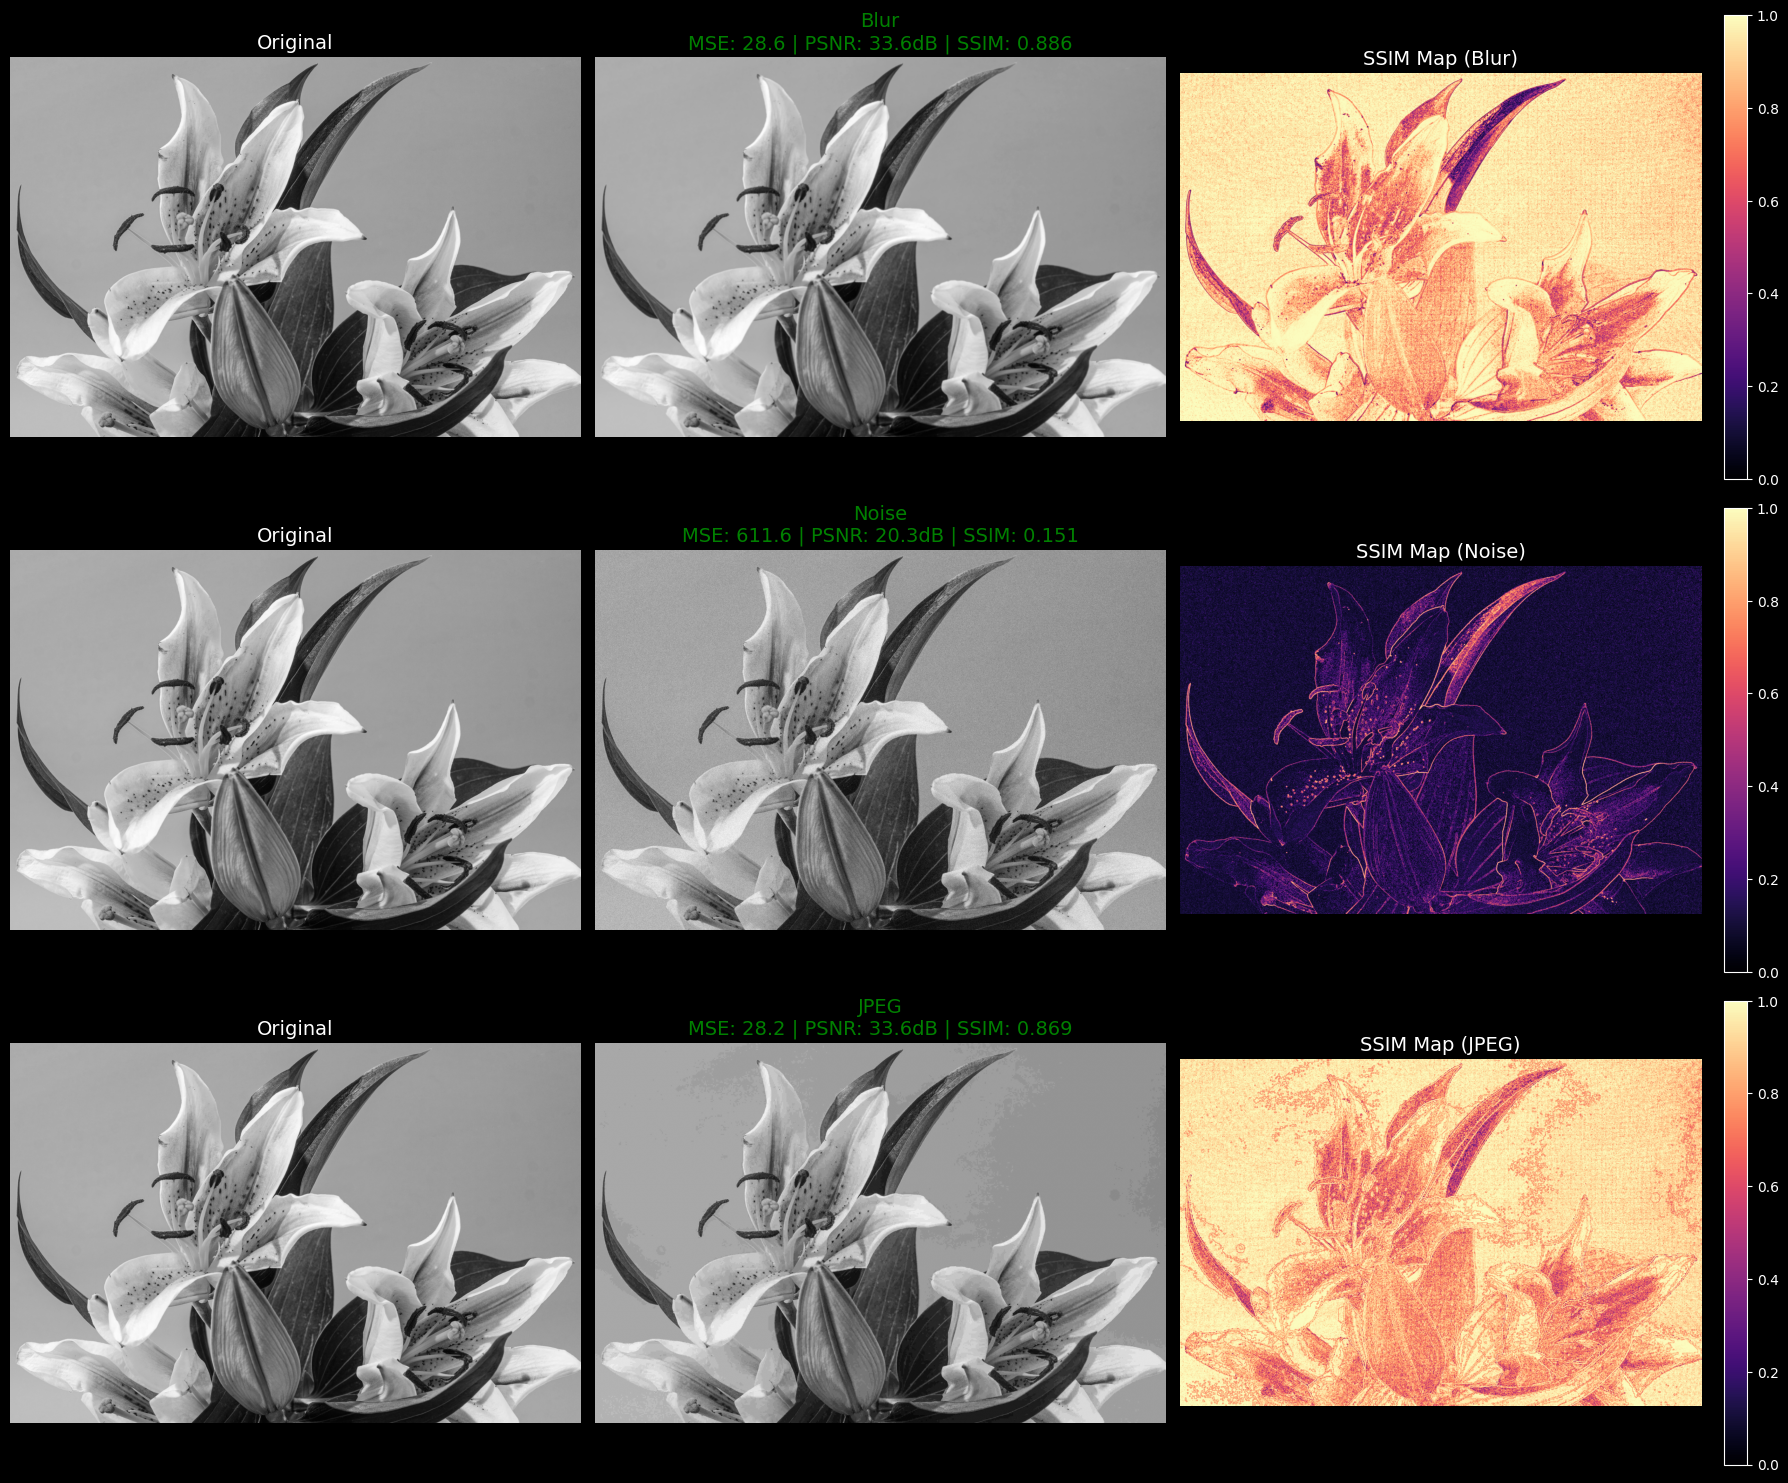

In [6]:
# 5. Visualize the Quality Maps
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Use a dark background to better highlight the heatmap variations in IQA
plt.style.use('dark_background') 

for idx, (name, distorted) in enumerate(distorted_imgs.items()):
    mse, psnr_val, ssim_val, ssim_map = metrics[name]
    
    # [Col 1] Original Image
    axes[idx, 0].imshow(original, cmap='gray')
    axes[idx, 0].set_title("Original", fontsize=14)
    axes[idx, 0].axis('off')
    
    # [Col 2] Distorted Image + Quantitative Metrics
    axes[idx, 1].imshow(distorted, cmap='gray')
    title = f"{name}\nMSE: {mse:.1f} | PSNR: {psnr_val:.1f}dB | SSIM: {ssim_val:.3f}"
    axes[idx, 1].set_title(title, fontsize=14, color='green')
    axes[idx, 1].axis('off')
    
    # [Col 3] SSIM Quality Map (Magma colormap for visual clarity)
    im = axes[idx, 2].imshow(ssim_map, vmin=0, vmax=1, cmap='magma')
    axes[idx, 2].set_title(f"SSIM Map ({name})", fontsize=14)
    axes[idx, 2].axis('off')
    
    # Add a colorbar to each map
    plt.colorbar(im, ax=axes[idx, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('ssim_experiments_result.png', dpi=300)
plt.show()

### 💡 Experimental Insights & Conclusion
1. **Quantitative Analysis of Distortions:**
   * **Blur:** Yielded an MSE of 28.6 (PSNR: 33.6dB) and an SSIM of 0.886. Despite pixel-level changes, the macroscopic structure (low-frequency correlation) is preserved, resulting in a relatively high structural score.
   * **Noise:** Yielded a massive MSE of 611.6 (PSNR: 20.3dB) and a severely dropped SSIM of 0.151. The random Gaussian noise completely disrupted the local structural covariance, resulting in a nearly black Quality Map.
   * **JPEG Compression:** Yielded an MSE of 28.2 (PSNR: 33.6dB) and an SSIM of 0.869. 
   
   *📌 Key Observation:* Notice that the **Blur** and **JPEG** images have nearly identical MSE and PSNR values (33.6dB), meaning traditional metrics consider their quality degradation to be equal. However, their SSIM Quality Maps reveal completely different structural artifacts, with the JPEG map successfully capturing the grid-like "blocking artifacts."

2. **SSIM's Structural Awareness:** The Quality Maps clearly demonstrate SSIM's mechanism. Bright regions indicate preserved structure, while dark regions indicate structural destruction. SSIM accurately penalizes the independent random noise while forgiving the structured blur, perfectly mirroring human visual perception.

3. **Application to AIGC:** This experiment reinforces why simple absolute-error metrics cannot be used to evaluate Generative Models (AIGC). Evaluating AI-generated content requires perception-based metrics (like SSIM, LPIPS) to accurately quantify structural anomalies, local artifacts, and perceptual quality.